<a href="https://colab.research.google.com/github/dixondanty/AI-ML-internship/blob/main/day8/flower%20recognition_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:


# Path to zip file
zip_path = "/content/archive.zip"

# Extract location
extract_path = "/content/extracted"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting")

Done extracting


In [ ]:
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    print(zip_ref.namelist())

['flowers/daisy/100080576_f52e8ee070_n.jpg', 'flowers/daisy/10140303196_b88d3d6cec.jpg', 'flowers/daisy/10172379554_b296050f82_n.jpg', 'flowers/daisy/10172567486_2748826a8b.jpg', 'flowers/daisy/10172636503_21bededa75_n.jpg', 'flowers/daisy/102841525_bd6628ae3c.jpg', 'flowers/daisy/10300722094_28fa978807_n.jpg', 'flowers/daisy/1031799732_e7f4008c03.jpg', 'flowers/daisy/10391248763_1d16681106_n.jpg', 'flowers/daisy/10437754174_22ec990b77_m.jpg', 'flowers/daisy/10437770546_8bb6f7bdd3_m.jpg', 'flowers/daisy/10437929963_bc13eebe0c.jpg', 'flowers/daisy/10466290366_cc72e33532.jpg', 'flowers/daisy/10466558316_a7198b87e2.jpg', 'flowers/daisy/10555749515_13a12a026e.jpg', 'flowers/daisy/10555815624_dc211569b0.jpg', 'flowers/daisy/10555826524_423eb8bf71_n.jpg', 'flowers/daisy/10559679065_50d2b16f6d.jpg', 'flowers/daisy/105806915_a9c13e2106_n.jpg', 'flowers/daisy/10712722853_5632165b04.jpg', 'flowers/daisy/107592979_aaa9cdfe78_m.jpg', 'flowers/daisy/10770585085_4742b9dac3_n.jpg', 'flowers/daisy/108

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    '/content/extracted/flowers',
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
val_data = datagen.flow_from_directory(
    '/content/extracted/flowers',
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [ ]:
print(train_data.class_indices)

{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [ ]:
print("Class Labels:", train_data.class_indices)

print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)

Class Labels: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
Training Samples: 3457
Validation Samples: 860


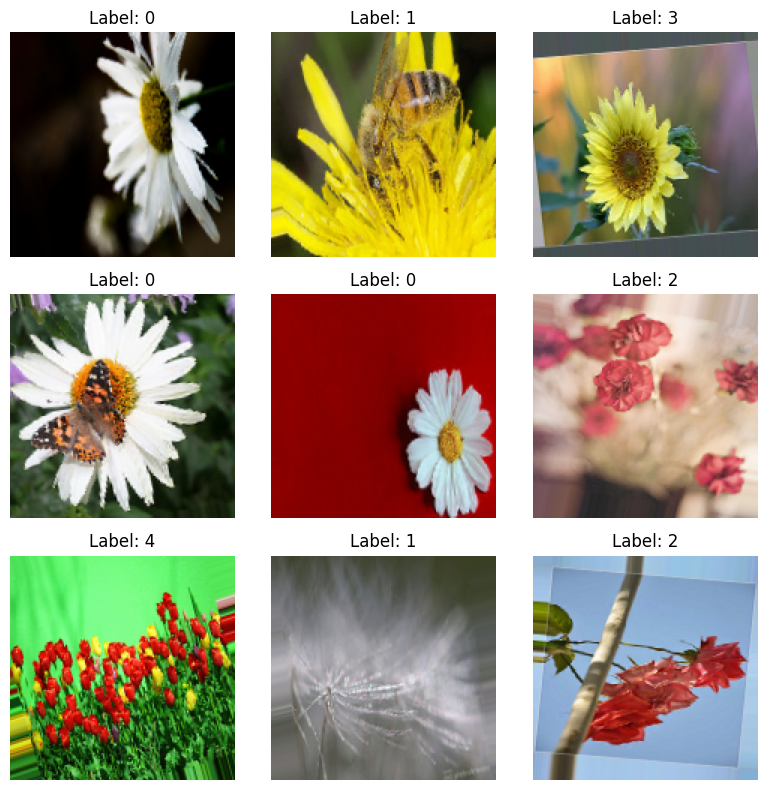

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),   # reduces overfitting

    Dense(5, activation='softmax')   # 5 flower classes
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,997 (18.42 MB)

 Trainable params: 4,828,997 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    epochs=7,
    validation_data=val_data,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/7
109/109 - 187s - 2s/step - accuracy: 0.3679 - loss: 1.4104 - val_accuracy: 0.4930 - val_loss: 1.1937
Epoch 2/7
109/109 - 188s - 2s/step - accuracy: 0.5201 - loss: 1.1735 - val_accuracy: 0.5663 - val_loss: 1.0462
Epoch 3/7
109/109 - 181s - 2s/step - accuracy: 0.5959 - loss: 1.0377 - val_accuracy: 0.5314 - val_loss: 1.0983
Epoch 4/7
109/109 - 183s - 2s/step - accuracy: 0.6219 - loss: 0.9746 - val_accuracy: 0.6558 - val_loss: 0.9015
Epoch 5/7
109/109 - 184s - 2s/step - accuracy: 0.6465 - loss: 0.9348 - val_accuracy: 0.6686 - val_loss: 0.8785
Epoch 6/7
109/109 - 182s - 2s/step - accuracy: 0.6754 - loss: 0.8648 - val_accuracy: 0.6709 - val_loss: 0.8175
Epoch 7/7
109/109 - 183s - 2s/step - accuracy: 0.6806 - loss: 0.8448 - val_accuracy: 0.7023 - val_loss: 0.7822


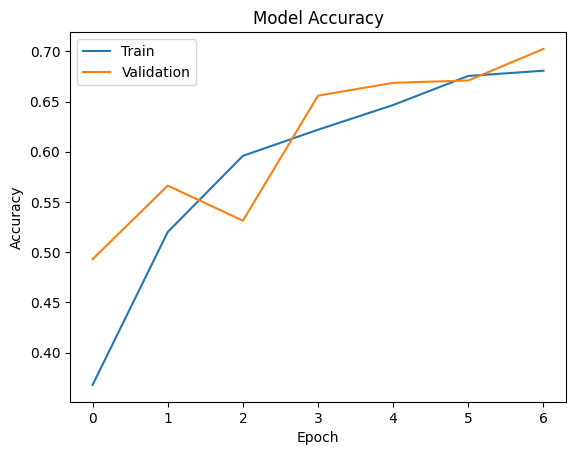

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

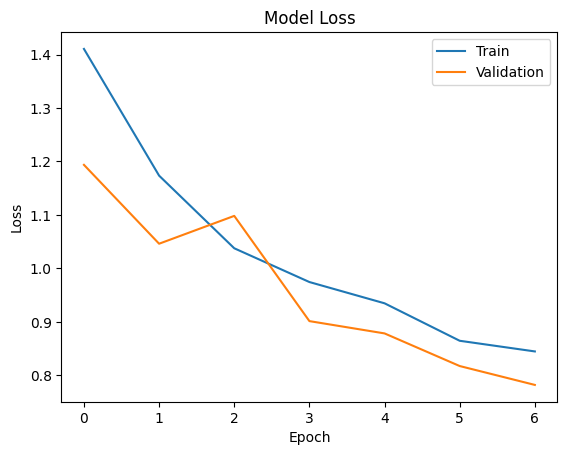

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(val_data)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 594ms/step - accuracy: 0.7058 - loss: 0.7829
Test Accuracy: 0.7058
Test Loss: 0.7829


In [ ]:
y_pred = model.predict(val_data)

# Predicted classes
y_pred_classes = np.argmax(y_pred, axis=1)

# True classes
y_true = val_data.classes

# Report
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=val_data.class_indices.keys()
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 601ms/step
              precision    recall  f1-score   support

       daisy       0.69      0.78      0.73       152
   dandelion       0.73      0.79      0.76       210
        rose       0.59      0.46      0.51       156
   sunflower       0.75      0.75      0.75       146
       tulip       0.65      0.66      0.65       196

    accuracy                           0.69       860
   macro avg       0.68      0.68      0.68       860
weighted avg       0.68      0.69      0.68       860



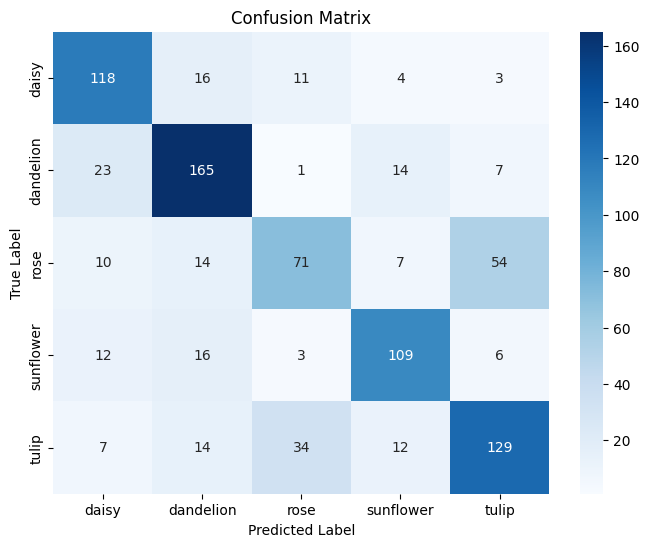

In [ ]:
# Create confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 595ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step


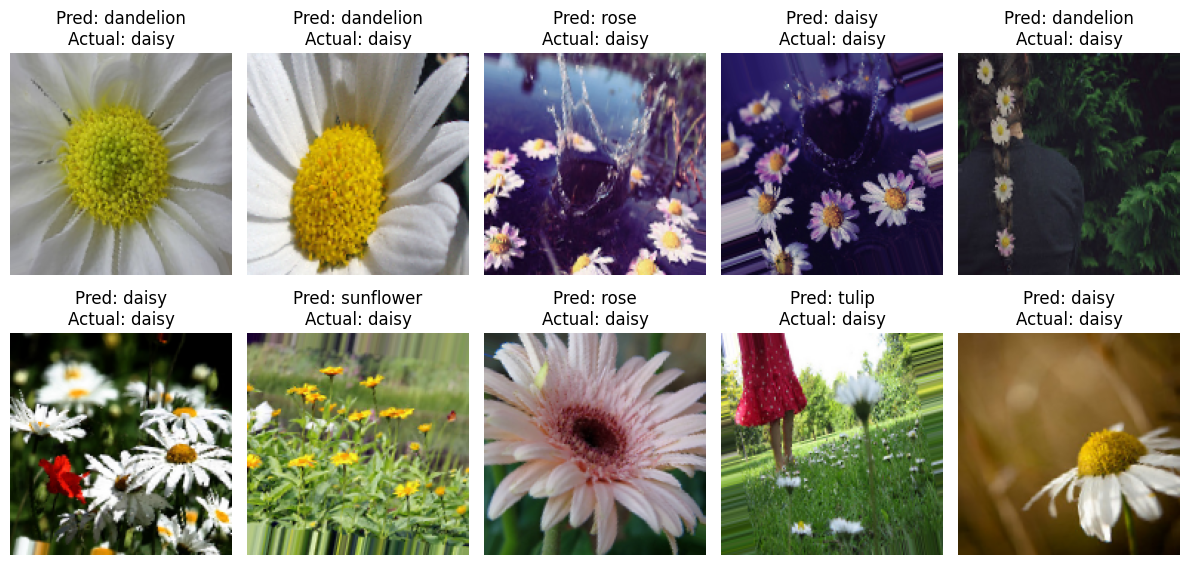

In [ ]:
images, labels = next(val_data)

predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i])

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\n"
        f"Actual: {class_names[true_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


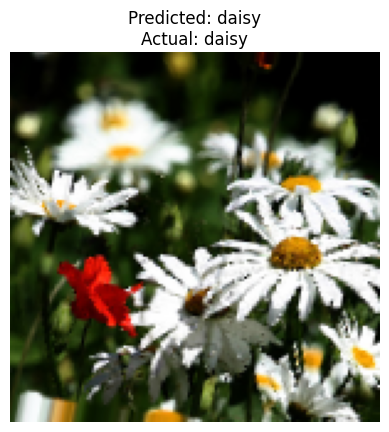

In [ ]:
# Select one image
index = 5

single_image = images[index].reshape(1,150,150,3)

# Predict
predicted_label = np.argmax(model.predict(single_image))

# Actual label
actual_label = np.argmax(labels[index])

# Class names
class_names = list(val_data.class_indices.keys())

# Display image
plt.imshow(images[index])

plt.title(
    f"Predicted: {class_names[predicted_label]}\n"
    f"Actual: {class_names[actual_label]}"
)

plt.axis('off')

plt.show()



In [ ]:
model.save("flower_model.keras")

In [71]:
model.save(
    "flower_model.h5",
    include_optimizer=False
)

In [73]:
!zip -r flower_model.zip flower_model.h5

  adding: flower_model.h5 (deflated 7%)


In [ ]:
!zip -r flower_model.zip flower_model.keras

  adding: flower_model.keras (deflated 12%)
